In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.style.use('seaborn-v0_8')
sns.set_context('talk')

In [ ]:
DATA_PATH = '.' # Expects 'traffic.csv' to be in the Colab root directory
FILE_NAME = 'traffic.csv'  # <-- This is the file for the tutorial, you need to upload it

# Try to read the CSV (adjust encoding or separator if needed)
file_path = os.path.join(DATA_PATH, FILE_NAME)
assert os.path.exists(file_path), f"File not found: {file_path}. Please place the dataset and update FILE_NAME."

df = pd.read_csv(file_path)
print('Shape:', df.shape)
print('Columns:', list(df.columns))

df.head()

Shape: (48120, 4)
Columns: ['DateTime', 'Junction', 'Vehicles', 'ID']


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Update FILE_NAME if it's the traffic.csv file
  if fn == 'traffic.csv':
      FILE_NAME = 'traffic.csv'
      print(f"Updated FILE_NAME to: {FILE_NAME}")
  else:
      print("Please ensure you upload 'traffic.csv'.")


Saving traffic.csv to traffic (3).csv
User uploaded file "traffic (3).csv" with length 1767271 bytes
Please ensure you upload 'traffic.csv'.


After uploading the file, please re-run the code cell that reads the CSV file to load the data into the DataFrame.

In [ ]:
TIMESTAMP_COL = "DateTime"
TARGET_COL = "Vehicles"

# Parse datetime if available
if TIMESTAMP_COL is not None and TIMESTAMP_COL in df.columns:
    df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors='coerce')

    # Drop rows where timestamp could not be parsed
    before = len(df)
    df = df.dropna(subset=[TIMESTAMP_COL]).copy()
    after = len(df)

    print(f"Dropped {before - after} rows due to unparsable timestamps.")
else:
    print("(Info) TIMESTAMP_COL not set or not found. Proceeding without explicit time parsing.")

# Simple safety check for target column
assert TARGET_COL in df.columns, "Please set TARGET_COL to a valid column name."

print("Timestamp column:", TIMESTAMP_COL)
print("Target column:", TARGET_COL)

Dropped 0 rows due to unparsable timestamps.
Timestamp column: DateTime
Target column: Vehicles


In [ ]:
# Basic structure
print(df.info())
df.describe(include='all').T.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  48120 non-null  datetime64[ns]
 1   Junction  48120 non-null  int64         
 2   Vehicles  48120 non-null  int64         
 3   ID        48120 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.5 MB
None


,count,mean,min,25%,50%,75%,max,std
DateTime,48120,2016-09-19 06:03:56.109725696,2015-11-01 00:00:00,2016-04-16 01:45:00,2016-09-30 03:30:00,2017-02-25 16:00:00,2017-06-30 23:00:00,NaN
Junction,48120.0,2.180549,1.0,1.0,2.0,3.0,4.0,0.966955
Vehicles,48120.0,22.791334,1.0,9.0,15.0,29.0,180.0,20.750063
ID,48120.0,20163302501.220448,20151101001.0,20160416019.0,20160930037.0,20170225162.25,20170630234.0,5944853.800152


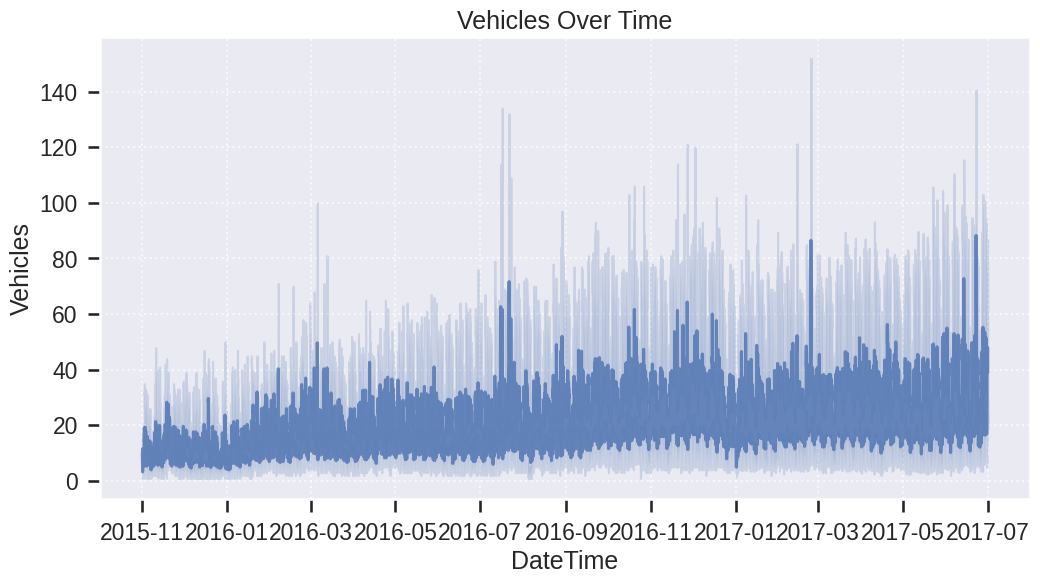

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure DateTime is parsed and sort for time series plot
df['DateTime'] = pd.to_datetime(df['DateTime'])
df_sorted = df.sort_values('DateTime')

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_sorted, x='DateTime', y='Vehicles', alpha=0.8)
plt.title('Vehicles Over Time')
plt.xlabel('DateTime')
plt.ylabel('Vehicles')
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing>0]

,0


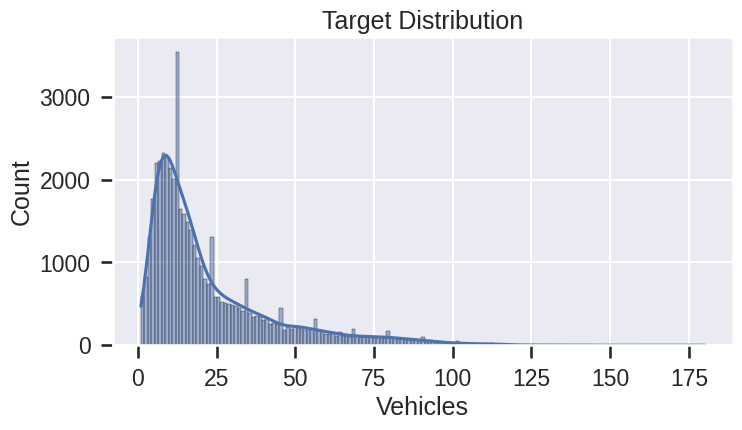

In [ ]:
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(df[TARGET_COL].dropna(), kde=True, ax=ax)
ax.set_title('Target Distribution')
ax.set_xlabel(TARGET_COL)
plt.show()

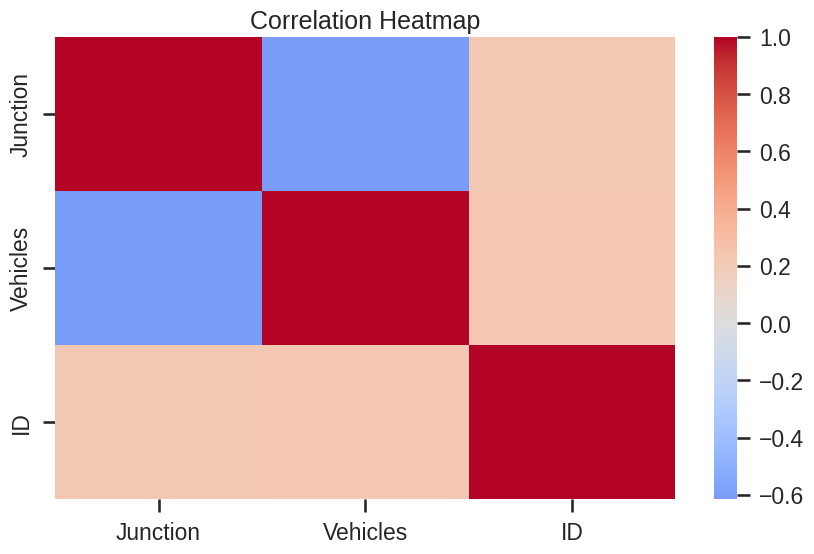

In [ ]:
plt.figure(figsize=(10, 6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

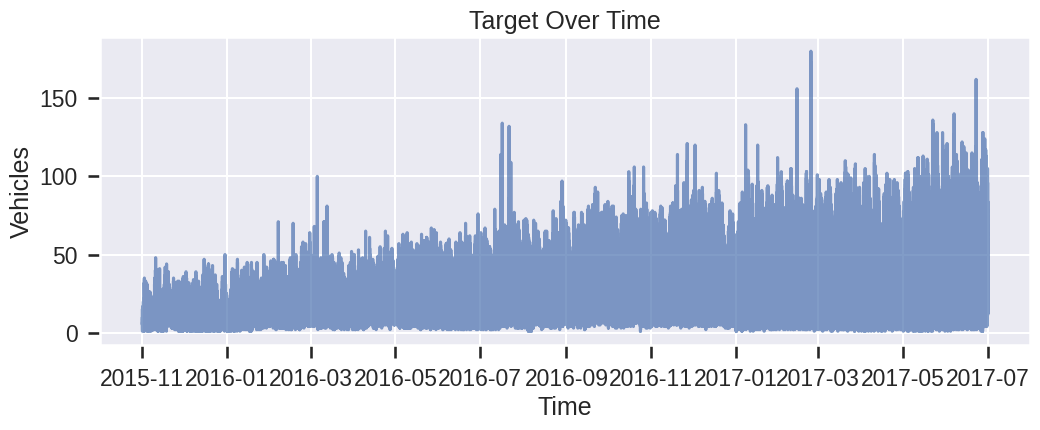

In [ ]:
if TIMESTAMP_COL is not None and TIMESTAMP_COL in df.columns:
    df_sorted = df.sort_values(TIMESTAMP_COL)
    fig, ax = plt.subplots(figsize=(12,4))
    ax.plot(df_sorted[TIMESTAMP_COL], df_sorted[TARGET_COL], alpha=0.7)
    ax.set_title('Target Over Time')
    ax.set_xlabel('Time')
    ax.set_ylabel(TARGET_COL)
    plt.show()
else:
    print("(Info) Skipping time plot – no TIMESTAMP_COL set.")


In [ ]:
feature_cols = [c for c in df.columns if c != TARGET_COL]
X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

# Identify column types
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
# (We will handle datetime-derived features separately during feature engineering.)

if TIMESTAMP_COL is not None and TIMESTAMP_COL in df.columns:
    # Time-aware split: sort by time and split by a cut point (e.g., last 20% as test)
    df_sorted = df.sort_values(TIMESTAMP_COL)
    split_idx = int(0.8 * len(df_sorted))
    train_df = df_sorted.iloc[:split_idx].copy()
    test_df  = df_sorted.iloc[split_idx:].copy()

    X_train = train_df[feature_cols]
    y_train = train_df[TARGET_COL]
    X_test  = test_df[feature_cols]
    y_test  = test_df[TARGET_COL]
else:
    # Random split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_SEED
    )

print('Train size:', len(X_train), ' Test size:', len(X_test))
print('Numeric:', len(numeric_cols), 'Categorical:', len(categorical_cols))

Train size: 38496  Test size: 9624
Numeric: 2 Categorical: 0


In [ ]:
# Column-wise transformers
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ], remainder='drop'
)

In [ ]:
if TIMESTAMP_COL is not None and TIMESTAMP_COL in df.columns:
    def add_time_features(frame):
        f = frame.copy()
        ts = pd.to_datetime(f[TIMESTAMP_COL], errors='coerce')
        f['hour'] = ts.dt.hour
        f['dayofweek'] = ts.dt.dayofweek
        f['month'] = ts.dt.month
        f['is_weekend'] = ts.dt.dayofweek >= 5
        return f

    # Apply to train/test consistently (avoid leakage by deriving only from given rows)
    X_train_fe = add_time_features(X_train)
    X_test_fe  = add_time_features(X_test)

    # Update categorical/numeric lists if needed
    numeric_cols = list(set(numeric_cols + ['hour','dayofweek','month']))
    if 'is_weekend' not in categorical_cols and 'is_weekend' in X_train_fe.columns:
        categorical_cols = categorical_cols + ['is_weekend']
else:
    X_train_fe, X_test_fe = X_train.copy(), X_test.copy()

print('Feature-engineered shapes:', X_train_fe.shape, X_test_fe.shape)

Feature-engineered shapes: (38496, 7) (9624, 7)


In [ ]:
X_train_fe = X_train_fe.copy()
X_test_fe = X_test_fe.copy()

# ---------------------------
# 1) Add LAG feature (lag_1)
# ---------------------------
# Shift the target by 1 step within each split
X_train_fe['lag_1'] = y_train.shift(1)
X_test_fe['lag_1'] = y_test.shift(1)

# ---------------------------
# 2) Add ROLLING MEAN feature (rolling_3)
# ---------------------------
# Rolling mean of past 3 target values
X_train_fe['rolling_3'] = y_train.shift(1).rolling(window=3).mean()
X_test_fe['rolling_3'] = y_test.shift(1).rolling(window=3).mean()

# ---------------------------
# 3) Handle missing values created by lag/rolling
# ---------------------------
# We drop the first few rows that have NaN due to lag/rolling
X_train_fe = X_train_fe.dropna()
y_train = y_train.loc[X_train_fe.index]

X_test_fe = X_test_fe.dropna()
y_test = y_test.loc[X_test_fe.index]

print("Lag & rolling features added!")
print("New shapes:", X_train_fe.shape, X_test_fe.shape)

Lag & rolling features added!
New shapes: (38493, 9) (9621, 9)


In [ ]:
# Decision Tree (Demonstration)
model_tree = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeRegressor(random_state=RANDOM_SEED, max_depth=None))
])
model_tree.fit(X_train_fe, y_train)
y_pred_tree = model_tree.predict(X_test_fe)
tree_mae = mean_absolute_error(y_test, y_pred_tree)
print(f"Decision Tree MAE: {tree_mae:.4f}")


Decision Tree MAE: 11.0446


In [ ]:
model_lin = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])
model_lin.fit(X_train_fe, y_train)
y_pred_lin = model_lin.predict(X_test_fe)
lin_mae = mean_absolute_error(y_test, y_pred_lin)
print(f"Linear Regression MAE: {lin_mae:.4f}")

Linear Regression MAE: 11.6256


In [ ]:
# Your Turn: Model #1
# Example skeleton:
# from sklearn.ensemble import RandomForestRegressor
# model_rf = Pipeline(steps=[
#     ("preprocess", preprocessor),
#     ("model", RandomForestRegressor(n_estimators=300, random_state=RANDOM_SEED))
# ])
# model_rf.fit(X_train_fe, y_train)
# y_pred_rf = model_rf.predict(X_test_fe)
# rf_mae = mean_absolute_error(y_test, y_pred_rf)
# print(f"Random Forest MAE: {rf_mae:.4f}")
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

model_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=RANDOM_SEED,
        n_jobs=-1
    ))
])

model_rf.fit(X_train_fe, y_train)
y_pred_rf = model_rf.predict(X_test_fe)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest MAE: {rf_mae:.4f}")




Random Forest MAE: 11.5826


In [ ]:
# Your Turn: Model #2
from sklearn.svm import SVR

model_svr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", SVR(
        kernel="rbf",
        C=10.0,
        epsilon=0.1
    ))
])

model_svr.fit(X_train_fe, y_train)
y_pred_svr = model_svr.predict(X_test_fe)
svr_mae = mean_absolute_error(y_test, y_pred_svr)

print(f"SVR MAE: {svr_mae:.4f}")


SVR MAE: 9.9155


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

model_knn = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsRegressor(
        n_neighbors=7,
        weights="distance"
    ))
])

model_knn.fit(X_train_fe, y_train)
y_pred_knn = model_knn.predict(X_test_fe)
knn_mae = mean_absolute_error(y_test, y_pred_knn)

print(f"KNN MAE: {knn_mae:.4f}")

KNN MAE: 12.2960


In [ ]:
# Collect MAEs; extend this dict with your models and your additional metrics
results = []

results.append({
    'model': 'Decision Tree',
    'mae': float(tree_mae),
    # Add more metrics here (e.g., 'rmse': ..., 'r2': ...)
})

results.append({
    'model': 'Linear Regression',
    'mae': float(lin_mae),
    # Add more metrics here
})

# If you trained extra models, append them similarly
# results.append({'model': 'Random Forest', 'mae': float(rf_mae)})


from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

results.append({
    'model': 'Random Forest',
    'mae': float(rf_mae),
    'rmse': float(rf_rmse),
    'r2': float(rf_r2)
})
results_df = pd.DataFrame(results)
results_df.sort_values('mae')



,model,mae,rmse,r2
0,Decision Tree,11.044590,NaN,NaN
2,Random Forest,11.582639,17.216678,0.599965
1,Linear Regression,11.625601,NaN,NaN


In [ ]:
# Choose the model to use for anomaly detection
chosen_model_name = 'Linear Regression'  # change to 'Decision Tree' or your best model

if chosen_model_name == 'Linear Regression':
    y_pred = y_pred_lin
elif chosen_model_name == 'Decision Tree':
    y_pred = y_pred_tree
else:
    # Add your own branches if you trained additional models, e.g. 'Random Forest'
    raise ValueError("Please set chosen_model_name to a trained model.")

residuals = y_test.values - y_pred
abs_res = np.abs(residuals)

summary = pd.Series(abs_res).describe(percentiles=[0.5, 0.9, 0.95, 0.99])
summary


,0
count,9621.000000
mean,11.625601
std,14.210550
min,0.010274
50%,6.680355
90%,31.576190
95%,46.562360
99%,64.477882
max,142.421707


In [ ]:
# Percentile-based thresholds
q90 = np.percentile(abs_res, 90)
q95 = np.percentile(abs_res, 95)
q99 = np.percentile(abs_res, 99)

thresholds = [
    (f"P90={q90:.3f}", q90),
    (f"P95={q95:.3f}", q95),
    (f"P99={q99:.3f}", q99),
]

anomaly_tables = []
for label, tau in thresholds:
    is_anom = abs_res > tau
    count = is_anom.sum()
    frac = count / len(abs_res)
    anomaly_tables.append({
        'threshold': label,
        'value': float(tau),
        'anomaly_count': int(count),
        'anomaly_frac': float(frac)
    })

anomalies_df = pd.DataFrame(anomaly_tables).sort_values('value')
anomalies_df


,threshold,value,anomaly_count,anomaly_frac
0,P90=31.576,31.576190,962,0.099990
1,P95=46.562,46.562360,481,0.049995
2,P99=64.478,64.477882,97,0.010082


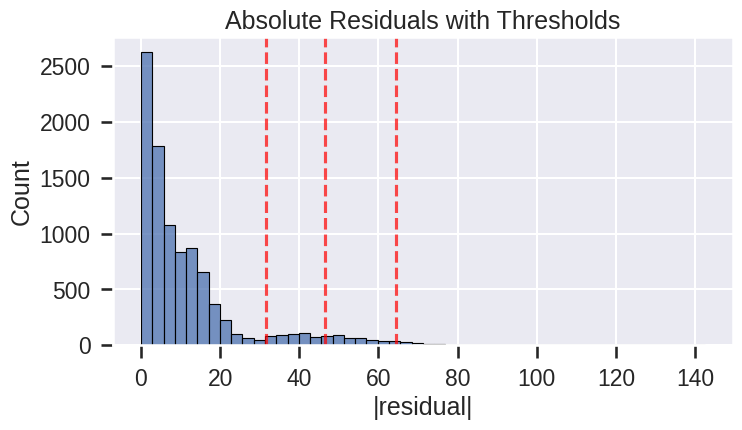

In [ ]:
# Residuals histogram with threshold lines
fig, ax = plt.subplots(figsize=(8,4))
sns.histplot(abs_res, bins=50, ax=ax)
for label, tau in thresholds:
    ax.axvline(tau, color='red', linestyle='--', alpha=0.7)
ax.set_title('Absolute Residuals with Thresholds')
ax.set_xlabel('|residual|')
plt.show()


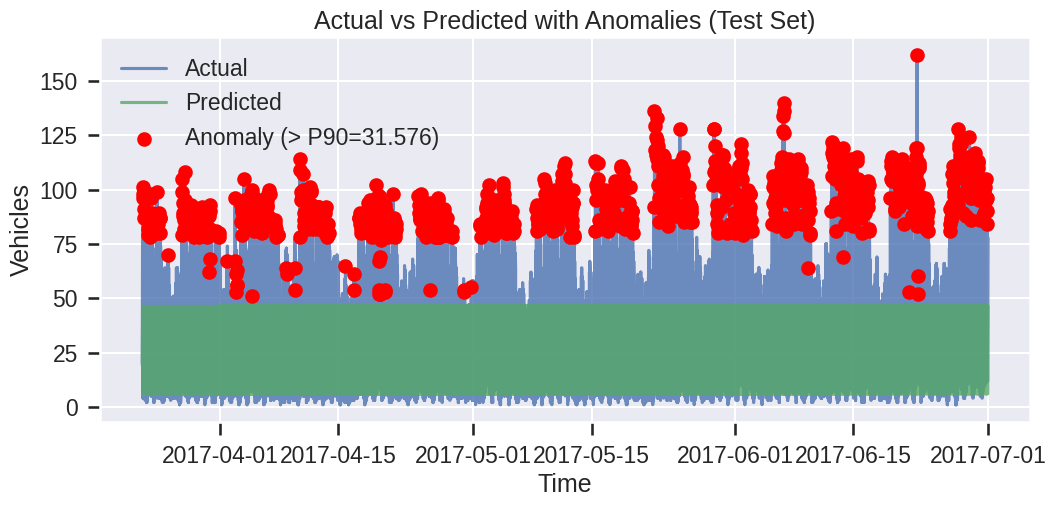

In [ ]:
# Actual vs Predicted over time with anomalies highlighted (if timestamp available)
if TIMESTAMP_COL is not None and TIMESTAMP_COL in df.columns:
    # We need the test timestamps, aligned with y_test order used above
    if TIMESTAMP_COL in X_test_fe.columns:
        ts_test = pd.to_datetime(X_test_fe[TIMESTAMP_COL])
    else:
        # If TIMESTAMP_COL was not retained in features (common), pull from the original test frame
        if 'test_df' in globals():
            ts_test = pd.to_datetime(test_df[TIMESTAMP_COL].iloc[:len(y_test)].values)
        else:
            ts_test = pd.Series(range(len(y_test)))  # fallback

    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(ts_test, y_test.values, label='Actual', alpha=0.8)
    ax.plot(ts_test, y_pred, label='Predicted', alpha=0.8)

    # Mark anomalies for the FIRST threshold in the list
    if len(thresholds) > 0:
        first_tau = thresholds[0][1]
        is_anom = abs_res > first_tau
        ax.scatter(ts_test[is_anom], y_test.values[is_anom], color='red', label=f'Anomaly (> {thresholds[0][0]})', zorder=3)

    ax.set_title('Actual vs Predicted with Anomalies (Test Set)')
    ax.set_xlabel('Time')
    ax.set_ylabel(TARGET_COL)
    ax.legend()
    plt.show()
else:
    print("(Info) Skipping time plot – no TIMESTAMP_COL set.")
